# 10_dani_ensemble_tuned
## Hyperparameter Optimization (Optuna) untuk Bobot Ensemble

Melanjutkan `09_dani_ensemble.ipynb`. Temuan penting dari nb09 yang jadi motivasi notebook ini:

| | CI | RE |
|---|---|---|
| Best individual model | `mstl BiLSTM CI` RMSE 2.0276 | `mstl Uni-LSTM RE` RMSE 0.2199 |
| Best ensemble (heuristik 1/RMSE) | RMSE 2.0128 (+0.73%) | RMSE 0.2227 (**-1.24%, lebih jelek!**) |

Bobot heuristik `1/RMSE` ternyata belum optimal — bahkan untuk RE, ensemble-nya kalah dari model
tunggal terbaik. Notebook ini mengganti heuristik itu dengan **bobot hasil pencarian Optuna** yang
langsung meminimalkan error kombinasi di **validation set** (bukan test — supaya pemilihan bobot
tidak ikut mengintip data test, sama seperti prinsip nb09).

### Yang dicari Optuna

Bukan arsitektur (tidak ada training model sama sekali di sini) — melainkan **bobot linear per model**
`w_1, ..., w_n` (dinormalisasi supaya jumlahnya 1) yang meminimalkan RMSE kombinasi pada validation set.
Karena tidak ada training, **tiap trial sangat murah** (cuma weighted-average + hitung RMSE) — jauh
lebih cepat dari nb08.

### Dua varian pencarian per target (sama seperti nb09)

- **`all`** — bobot dicari bebas di antara semua 8 model yang berkontribusi (termasuk model univariate)
  — upper-bound: seberapa bagus ensemble BISA jadi kalau tidak dibatasi premis penelitian.
- **`multi_only`** — bobot dicari HANYA di antara `Multi-LSTM` + `BiLSTM Multi` (4 model: 2 arsitektur ×
  2 metode dekomposisi) — **ini yang direkomendasikan untuk dilaporkan**, karena konsisten dengan premis
  "berbasis Renewable Energy" pada judul penelitian.

### Catatan desain

Bobot dicari berdasarkan performa **one-step di validation set**, lalu bobot yang sama dipakai untuk
evaluasi one-step maupun multistep di test set (simplifikasi umum di literatur — tuning bobot terpisah
untuk tiap horizon multistep akan jauh lebih mahal dan datanya lebih sedikit per horizon).

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

project_root = next(
    (parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "src").exists()),
    Path.cwd()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import TimeSeriesDataLoader

import tensorflow as tf
from prophet import Prophet

try:
    import optuna
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Project root:", project_root)
print("TensorFlow:", tf.__version__)
print("Optuna:", optuna.__version__)

Project root: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app
TensorFlow: 2.21.0
Optuna: 4.9.0


In [2]:
feature_path = (
    project_root / "data" / "processed" / "normalized" / "dataset_feature_engineered.csv"
)

df = pd.read_csv(feature_path)
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.set_index("datetime").sort_index()

CI_COL = "carbon_intensity"
RE_COL = "renewable_percentage"

df_core = df.dropna(subset=[CI_COL, RE_COL]).copy()

TRAIN_RATIO = 0.8
train_size = int(len(df_core) * TRAIN_RATIO)
train_raw = df_core.iloc[:train_size].copy()
test_raw = df_core.iloc[train_size:].copy()
TRAIN_END_INDEX = train_raw.index[-1]

print("Train:", train_raw.shape, "| Test:", test_raw.shape)

Train: (13996, 84) | Test: (3500, 84)


In [3]:
TEMPORAL_CYCLICAL = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

loader_time = TimeSeriesDataLoader()
all_index_df = pd.DataFrame(index=df_core.index)
cyclical_full = loader_time.add_time_features(all_index_df)[TEMPORAL_CYCLICAL].copy()

print("Cyclical features ready.")

Cyclical features ready.


## 1. Decomposition (reused exactly from nb07/08/09)

In [4]:
def compute_causal_decomposition(series, train_end_index, trend_window=168):
    trend = series.rolling(window=trend_window, min_periods=1).mean()
    deseasonalized = series - trend

    train_deseasonalized = deseasonalized.loc[:train_end_index]

    hour_profile = train_deseasonalized.groupby(train_deseasonalized.index.hour).mean()
    seasonal_24 = pd.Series(series.index.hour.map(hour_profile).astype(float), index=series.index)

    residual_after_24 = (
        train_deseasonalized.values
        - train_deseasonalized.index.hour.map(hour_profile).astype(float)
    )
    weekhour_key_train = train_deseasonalized.index.weekday * 24 + train_deseasonalized.index.hour
    weekhour_profile = pd.Series(residual_after_24, index=weekhour_key_train).groupby(level=0).mean()
    weekhour_key_full = series.index.weekday * 24 + series.index.hour
    seasonal_168 = pd.Series(weekhour_key_full.map(weekhour_profile).astype(float), index=series.index)

    resid = series - trend - seasonal_24 - seasonal_168

    return pd.DataFrame(
        {"trend": trend, "seasonal_24": seasonal_24, "seasonal_168": seasonal_168, "resid": resid},
        index=series.index
    )


mstl_ci = compute_causal_decomposition(df_core[CI_COL], TRAIN_END_INDEX, trend_window=168)
mstl_re = compute_causal_decomposition(df_core[RE_COL], TRAIN_END_INDEX, trend_window=168)

mstl_decomposition = {
    "CI_reconstruction": mstl_ci["trend"] + mstl_ci["seasonal_24"] + mstl_ci["seasonal_168"],
    "CI_resid": mstl_ci["resid"],
    "RE_reconstruction": mstl_re["trend"] + mstl_re["seasonal_24"] + mstl_re["seasonal_168"],
    "RE_resid": mstl_re["resid"],
}
print("MSTL decomposition ready.")

MSTL decomposition ready.


In [5]:
def run_prophet_decomposition(target_col):
    prophet_df = df_core.reset_index()[["datetime", target_col]].copy()
    prophet_df["datetime"] = prophet_df["datetime"].dt.tz_localize(None)
    prophet_df.columns = ["ds", "y"]

    train_prophet_df = prophet_df.iloc[:train_size]
    test_prophet_df = prophet_df.iloc[train_size:]

    model = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True)
    model.fit(train_prophet_df)

    future = model.make_future_dataframe(periods=len(test_prophet_df), freq="h")
    forecast = model.predict(future)
    assert len(forecast) == len(df_core), "Prophet future length mismatch."

    reconstruction = pd.Series(forecast["yhat"].values, index=df_core.index)
    resid = df_core[target_col] - reconstruction
    return reconstruction, resid


print("Fitting Prophet on CI...")
ci_prophet_reconstruction, ci_prophet_resid = run_prophet_decomposition(CI_COL)
print("Fitting Prophet on RE...")
re_prophet_reconstruction, re_prophet_resid = run_prophet_decomposition(RE_COL)

prophet_decomposition = {
    "CI_reconstruction": ci_prophet_reconstruction,
    "CI_resid": ci_prophet_resid,
    "RE_reconstruction": re_prophet_reconstruction,
    "RE_resid": re_prophet_resid,
}

decompositions = {"mstl": mstl_decomposition, "prophet": prophet_decomposition}
print("Prophet decomposition ready.")

Fitting Prophet on CI...


19:19:50 - cmdstanpy - INFO - Chain [1] start processing
19:19:52 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet on RE...


19:19:53 - cmdstanpy - INFO - Chain [1] start processing
19:19:55 - cmdstanpy - INFO - Chain [1] done processing


Prophet decomposition ready.


In [6]:
def build_residual_dataframe(decomp):
    df_resid = pd.DataFrame(index=df_core.index)
    df_resid["CI_resid"] = decomp["CI_resid"]
    df_resid["RE_resid"] = decomp["RE_resid"]
    df_resid[TEMPORAL_CYCLICAL] = cyclical_full[TEMPORAL_CYCLICAL]
    return df_resid


def get_feature_target_cols(target_group):
    if target_group == "CI":
        return ["CI_resid", *TEMPORAL_CYCLICAL], ["CI_resid"]
    elif target_group == "RE":
        return ["RE_resid", *TEMPORAL_CYCLICAL], ["RE_resid"]
    elif target_group == "MULTI":
        return ["CI_resid", "RE_resid", *TEMPORAL_CYCLICAL], ["CI_resid", "RE_resid"]
    raise ValueError("target_group must be CI, RE, or MULTI")


def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    nonzero = y_true != 0
    mape = (
        np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
        if np.any(nonzero) else np.nan
    )
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2}


experiment_specs = [
    ("Uni-LSTM CI", "CI", "lstm"),
    ("Uni-LSTM RE", "RE", "lstm"),
    ("Multi-LSTM", "MULTI", "lstm"),
    ("BiLSTM CI", "CI", "bilstm"),
    ("BiLSTM RE", "RE", "bilstm"),
    ("BiLSTM Multi", "MULTI", "bilstm"),
]
decomposition_methods = ["mstl", "prophet"]

## 2. SOURCE toggle — sama seperti nb09

In [7]:
SOURCE = "nb07"  # ganti ke "nb08" begitu tuning hybrid selesai

TUNED_LOOK_BACK = 12

def safe_name(model_name):
    return model_name.lower().replace(" ", "_").replace("-", "")

if SOURCE == "nb07":
    models_dir = project_root / "models" / "hybrid"
    def model_path(method, model_name):
        return models_dir / f"07_hybrid_{method}_{safe_name(model_name)}.keras"
    look_back_lookup = {
        (method, model_name): TUNED_LOOK_BACK
        for method in decomposition_methods
        for model_name, _, _ in experiment_specs
    }

elif SOURCE == "nb08":
    models_dir = project_root / "models" / "hybrid_tuned"
    def model_path(method, model_name):
        return models_dir / f"08_hybrid_tuned_{method}_{safe_name(model_name)}.keras"

    best_params_path = project_root / "results" / "hybrid_tuned" / "08_dani_hybrid_tuned_best_params.csv"
    best_params_df = pd.read_csv(best_params_path)
    look_back_lookup = {
        (row["Decomposition"], row["Model"]): int(row["look_back"])
        for _, row in best_params_df.iterrows()
    }

else:
    raise ValueError("SOURCE must be 'nb07' or 'nb08'")

print("SOURCE:", SOURCE, "| Models dir:", models_dir)

SOURCE: nb07 | Models dir: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/models/hybrid


## 3. Load all 12 base models + validation AND test predictions (raw scale)

Beda dari nb09: di sini butuh **deretan prediksi validation** per model (bukan cuma RMSE skalar-nya),
supaya Optuna bisa mengombinasikannya dengan bobot kandidat dan menghitung RMSE gabungan secara
langsung di tiap trial.

In [8]:
VALIDATION_SPLIT = 0.1
FORECAST_HORIZON = 1

def get_validation_arrays(X, y, validation_split=VALIDATION_SPLIT):
    n_val = max(1, int(len(X) * validation_split))
    return X[-n_val:], y[-n_val:]


base_models = {}

for method in decomposition_methods:
    decomp = decompositions[method]
    df_resid = build_residual_dataframe(decomp)

    for model_name, target_group, architecture in experiment_specs:
        look_back = look_back_lookup[(method, model_name)]
        feature_cols, target_cols = get_feature_target_cols(target_group)

        path = model_path(method, model_name)
        if not path.exists():
            print(f"WARNING: missing model file, skipped: {path}")
            continue

        model = tf.keras.models.load_model(path)

        loader = TimeSeriesDataLoader()
        train_scaled, test_scaled = loader.split_and_scale(
            df=df_resid, feature_cols=feature_cols, target_cols=target_cols, train_ratio=TRAIN_RATIO
        )
        X_train, y_train = loader.create_sliding_window(
            train_scaled, target_cols=target_cols, look_back=look_back, forecast_horizon=FORECAST_HORIZON
        )
        X_test, y_test = loader.create_sliding_window(
            test_scaled, target_cols=target_cols, look_back=look_back, forecast_horizon=FORECAST_HORIZON
        )
        X_val, y_val = get_validation_arrays(X_train, y_train)

        train_window_index = train_scaled.index[look_back:]
        val_index = train_window_index[-len(y_val):]
        own_test_index = test_raw.index[look_back:]

        # --- validation predictions (raw scale) ---
        val_pred_scaled = model.predict(X_val, verbose=0)
        if len(target_cols) == 1:
            val_pred_scaled = val_pred_scaled.reshape(-1)
        val_pred_inv = loader.inverse_transform_predictions(val_pred_scaled, target_cols, feature_cols)

        # --- test predictions (raw scale) ---
        test_pred_scaled = model.predict(X_test, verbose=0)
        if len(target_cols) == 1:
            test_pred_scaled = test_pred_scaled.reshape(-1)
        test_pred_inv = loader.inverse_transform_predictions(test_pred_scaled, target_cols, feature_cols)

        val_preds_by_target, test_preds_by_target = {}, {}
        for i, col in enumerate(target_cols):
            target_name = "CI" if col.startswith("CI") else "RE"

            recon_val = decomp[f"{target_name}_reconstruction"].loc[val_index].values
            recon_test = decomp[f"{target_name}_reconstruction"].loc[own_test_index].values

            if len(target_cols) == 1:
                val_final = val_pred_inv.reshape(-1) + recon_val
                test_final = test_pred_inv.reshape(-1) + recon_test
            else:
                val_final = val_pred_inv[:, i] + recon_val
                test_final = test_pred_inv[:, i] + recon_test

            val_preds_by_target[target_name] = pd.Series(val_final, index=val_index)
            test_preds_by_target[target_name] = pd.Series(test_final, index=own_test_index)

        base_models[(method, model_name)] = {
            "target_group": target_group,
            "look_back": look_back,
            "val_index": val_index,
            "val_pred": val_preds_by_target,
            "test_pred": test_preds_by_target,
        }

        print(f"Loaded: {model_name} | {method} | look_back={look_back}")

print("\nTotal base models loaded:", len(base_models))

Split: Train=13996, Test=3500
Features scaled: 7
  Sliding window: X=(13984, 12, 7), y=(13984,)
  Sliding window: X=(3488, 12, 7), y=(3488,)
Loaded: Uni-LSTM CI | mstl | look_back=12
Split: Train=13996, Test=3500
Features scaled: 7
  Sliding window: X=(13984, 12, 7), y=(13984,)
  Sliding window: X=(3488, 12, 7), y=(3488,)
Loaded: Uni-LSTM RE | mstl | look_back=12
Split: Train=13996, Test=3500
Features scaled: 8
  Sliding window: X=(13984, 12, 8), y=(13984, 2)
  Sliding window: X=(3488, 12, 8), y=(3488, 2)
Loaded: Multi-LSTM | mstl | look_back=12
Split: Train=13996, Test=3500
Features scaled: 7
  Sliding window: X=(13984, 12, 7), y=(13984,)
  Sliding window: X=(3488, 12, 7), y=(3488,)
Loaded: BiLSTM CI | mstl | look_back=12
Split: Train=13996, Test=3500
Features scaled: 7
  Sliding window: X=(13984, 12, 7), y=(13984,)
  Sliding window: X=(3488, 12, 7), y=(3488,)
Loaded: BiLSTM RE | mstl | look_back=12
Split: Train=13996, Test=3500
Features scaled: 8
  Sliding window: X=(13984, 12, 8), y

## 4. Align validation & test windows across all models (common index)

In [9]:
MAX_LOOK_BACK = max(bundle["look_back"] for bundle in base_models.values())
common_test_index = test_raw.index[MAX_LOOK_BACK:]

# Common validation index: trim every model's own validation index to the SAME length
# from the end (they all end at the same last train timestamp regardless of look_back).
common_val_size = min(len(b["val_index"]) for b in base_models.values())
common_val_index = list(base_models.values())[0]["val_index"][-common_val_size:]

for key, bundle in base_models.items():
    tail = bundle["val_index"][-common_val_size:]
    assert list(tail) == list(common_val_index), f"Validation index misaligned for {key}"

print("MAX_LOOK_BACK:", MAX_LOOK_BACK)
print("Common validation window:", len(common_val_index), "rows")
print("Common test window:", len(common_test_index), "rows")

MAX_LOOK_BACK: 12
Common validation window: 1398 rows
Common test window: 3488 rows


## 5. Optuna weight search — per target, per subset (`all` vs `multi_only`)

In [10]:
def get_contributing_models(target_name, multi_only=False):
    keys = []
    for key, bundle in base_models.items():
        if multi_only and bundle["target_group"] != "MULTI":
            continue
        if target_name not in bundle["val_pred"]:
            continue
        keys.append(key)
    return keys


def make_weight_objective(target_name, keys):
    val_actual = df_core.loc[common_val_index, CI_COL if target_name == "CI" else RE_COL].values
    val_preds = np.column_stack([
        base_models[key]["val_pred"][target_name].reindex(common_val_index).values
        for key in keys
    ])  # shape (n_val, n_models)

    def objective(trial):
        raw_weights = np.array([trial.suggest_float(f"w_{i}", 0.0, 1.0) for i in range(len(keys))])
        total = raw_weights.sum()
        if total < 1e-8:
            return 1e9  # degenerate all-zero weights - reject
        weights = raw_weights / total

        combined = val_preds @ weights
        rmse = np.sqrt(np.mean((val_actual - combined) ** 2))
        return rmse

    return objective


N_TRIALS = 300  # murah (tidak ada training) - bisa dinaikkan lagi kalau perlu

tuned_weights = {}
weight_search_results = []

for target_name in ["CI", "RE"]:
    for label, multi_only in [("all", False), ("multi_only", True)]:
        keys = get_contributing_models(target_name, multi_only=multi_only)
        if len(keys) == 0:
            continue

        objective = make_weight_objective(target_name, keys)
        sampler = optuna.samplers.TPESampler(seed=42)
        study = optuna.create_study(direction="minimize", sampler=sampler)
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

        raw_weights = np.array([study.best_params[f"w_{i}"] for i in range(len(keys))])
        weights = raw_weights / raw_weights.sum()

        tuned_weights[(target_name, label)] = dict(zip(keys, weights))
        weight_search_results.append({
            "Target": target_name, "Subset": label, "N_models": len(keys),
            "Best_val_RMSE": study.best_value
        })

        print(f"{target_name} | {label}: best val_RMSE={study.best_value:.4f}")
        for key, w in zip(keys, weights):
            print(f"    {key[0]}_{key[1]}: {w:.4f}")

weight_search_results_df = pd.DataFrame(weight_search_results)

CI | all: best val_RMSE=1.8936
    mstl_Uni-LSTM CI: 0.2301
    mstl_Multi-LSTM: 0.0340
    mstl_BiLSTM CI: 0.0348
    mstl_BiLSTM Multi: 0.2224
    prophet_Uni-LSTM CI: 0.0178
    prophet_Multi-LSTM: 0.1018
    prophet_BiLSTM CI: 0.2074
    prophet_BiLSTM Multi: 0.1519
CI | multi_only: best val_RMSE=1.9079
    mstl_Multi-LSTM: 0.0004
    mstl_BiLSTM Multi: 0.5928
    prophet_Multi-LSTM: 0.1242
    prophet_BiLSTM Multi: 0.2827
RE | all: best val_RMSE=0.2130
    mstl_Uni-LSTM RE: 0.0133
    mstl_Multi-LSTM: 0.0110
    mstl_BiLSTM RE: 0.2087
    mstl_BiLSTM Multi: 0.1218
    prophet_Uni-LSTM RE: 0.0118
    prophet_Multi-LSTM: 0.2347
    prophet_BiLSTM RE: 0.2871
    prophet_BiLSTM Multi: 0.1117
RE | multi_only: best val_RMSE=0.2156
    mstl_Multi-LSTM: 0.0570
    mstl_BiLSTM Multi: 0.3457
    prophet_Multi-LSTM: 0.3364
    prophet_BiLSTM Multi: 0.2609


## 6. Apply tuned weights — one-step test evaluation

In [11]:
tuned_ensemble_results = []
tuned_ensemble_predictions = {}

for target_name in ["CI", "RE"]:
    actual = df_core.loc[common_test_index, CI_COL if target_name == "CI" else RE_COL].values

    for label in ["all", "multi_only"]:
        if (target_name, label) not in tuned_weights:
            continue
        weights_dict = tuned_weights[(target_name, label)]

        combined = np.zeros(len(common_test_index))
        for key, w in weights_dict.items():
            pred = base_models[key]["test_pred"][target_name].reindex(common_test_index).values
            combined += w * pred

        metrics = evaluate(actual, combined)
        tuned_ensemble_results.append({
            "Ensemble": f"Ensemble-OptunaTuned ({label})", "Target": target_name,
            "N_models": len(weights_dict), **metrics
        })

        if label == "multi_only":
            tuned_ensemble_predictions[target_name] = pd.Series(combined, index=common_test_index)

tuned_ensemble_results_df = pd.DataFrame(tuned_ensemble_results)
print("=== ONE-STEP OPTUNA-TUNED ENSEMBLE EVALUATION ===")
display(tuned_ensemble_results_df.sort_values(["Target", "RMSE"]).reset_index(drop=True))

=== ONE-STEP OPTUNA-TUNED ENSEMBLE EVALUATION ===


,Ensemble,Target,N_models,MAE,RMSE,MAPE (%),R2
0,Ensemble-OptunaTuned (multi_only),CI,4,1.510975,2.012146,0.258751,0.950263
1,Ensemble-OptunaTuned (all),CI,8,1.511354,2.014357,0.258759,0.950154
2,Ensemble-OptunaTuned (all),RE,8,0.163442,0.220054,1.033379,0.955694
3,Ensemble-OptunaTuned (multi_only),RE,4,0.173328,0.228837,1.096125,0.952087


In [12]:
# Compare: best individual model vs heuristic ensemble (nb09) vs Optuna-tuned ensemble.
individual_results = []
for key, bundle in base_models.items():
    for target_name, pred in bundle["test_pred"].items():
        pred_aligned = pred.reindex(common_test_index)
        actual = df_core.loc[common_test_index, CI_COL if target_name == "CI" else RE_COL].values
        metrics = evaluate(actual, pred_aligned.values)
        individual_results.append({"Model": f"{key[0]}_{key[1]}", "Target": target_name, **metrics})

individual_results_df = pd.DataFrame(individual_results)

for target_name in ["CI", "RE"]:
    best_individual = individual_results_df[individual_results_df["Target"] == target_name].sort_values("RMSE").iloc[0]
    best_tuned = tuned_ensemble_results_df[tuned_ensemble_results_df["Target"] == target_name].sort_values("RMSE").iloc[0]

    print(f"--- {target_name} ---")
    print(f"Best individual model      : {best_individual['Model']:30s} RMSE={best_individual['RMSE']:.4f}")
    print(f"Best Optuna-tuned ensemble : {best_tuned['Ensemble']:30s} RMSE={best_tuned['RMSE']:.4f}")
    improvement = (best_individual["RMSE"] - best_tuned["RMSE"]) / best_individual["RMSE"] * 100
    print(f"Improvement over best individual: {improvement:.2f}%\n")

--- CI ---
Best individual model      : mstl_BiLSTM CI                 RMSE=2.0276
Best Optuna-tuned ensemble : Ensemble-OptunaTuned (multi_only) RMSE=2.0121
Improvement over best individual: 0.76%

--- RE ---
Best individual model      : mstl_Uni-LSTM RE               RMSE=0.2199
Best Optuna-tuned ensemble : Ensemble-OptunaTuned (all)     RMSE=0.2201
Improvement over best individual: -0.05%



## 7. Multistep — bobot yang sama dipakai untuk rolling-origin recursive forecast

In [13]:
MULTISTEP_HORIZON = 24
ORIGIN_STRIDE = 24
N_ORIGINS_MAX = 100


def rolling_origin_recursive_forecast(model, loader, test_scaled, feature_cols, target_cols, horizon, look_back, origins):
    data = test_scaled[feature_cols].values
    target_idx = [feature_cols.index(c) for c in target_cols]

    per_origin_preds = []
    for origin in origins:
        history_window = data[origin - look_back: origin].copy()
        preds_scaled = []
        for h in range(horizon):
            X_step = history_window[np.newaxis, :, :]
            pred_scaled = model.predict(X_step, verbose=0).reshape(-1)
            preds_scaled.append(pred_scaled)
            next_row = data[origin + h].copy()
            for i, idx in enumerate(target_idx):
                next_row[idx] = pred_scaled[i]
            history_window = np.vstack([history_window[1:], next_row])
        preds_scaled = np.array(preds_scaled)
        preds_inv = loader.inverse_transform_predictions(preds_scaled, target_cols=target_cols, feature_cols=feature_cols)
        per_origin_preds.append((origin, preds_inv))
    return per_origin_preds


sample_test_len = len(test_raw)
shared_origins = list(range(MAX_LOOK_BACK, sample_test_len - MULTISTEP_HORIZON, ORIGIN_STRIDE))[:N_ORIGINS_MAX]

base_multistep_preds = {}
for method in decomposition_methods:
    decomp = decompositions[method]
    df_resid = build_residual_dataframe(decomp)

    for model_name, target_group, architecture in experiment_specs:
        key = (method, model_name)
        if key not in base_models:
            continue

        feature_cols, target_cols = get_feature_target_cols(target_group)
        look_back = base_models[key]["look_back"]

        model = tf.keras.models.load_model(model_path(method, model_name))
        loader = TimeSeriesDataLoader()
        _, test_scaled = loader.split_and_scale(df_resid, feature_cols, target_cols, train_ratio=TRAIN_RATIO)

        per_origin_preds = rolling_origin_recursive_forecast(
            model, loader, test_scaled, feature_cols, target_cols,
            horizon=MULTISTEP_HORIZON, look_back=look_back, origins=shared_origins
        )

        per_target_grid = {}
        for origin, preds_inv in per_origin_preds:
            preds_inv = np.atleast_2d(preds_inv)
            if preds_inv.shape[0] == 1 and len(target_cols) > 1:
                preds_inv = preds_inv.reshape(-1, len(target_cols))
            elif preds_inv.ndim == 1:
                preds_inv = preds_inv.reshape(-1, 1)

            origin_index = test_scaled.index[origin: origin + MULTISTEP_HORIZON]
            for i, col in enumerate(target_cols):
                target_name = "CI" if col.startswith("CI") else "RE"
                recon_vals = decomp[f"{target_name}_reconstruction"].loc[origin_index].values
                final_pred = preds_inv[:, i] + recon_vals
                per_target_grid.setdefault(target_name, {})[origin] = final_pred

        base_multistep_preds[key] = per_target_grid
        print(f"Multistep done: {model_name} | {method}")

Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: Uni-LSTM CI | mstl
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: Uni-LSTM RE | mstl
Split: Train=13996, Test=3500
Features scaled: 8
Multistep done: Multi-LSTM | mstl
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: BiLSTM CI | mstl
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: BiLSTM RE | mstl
Split: Train=13996, Test=3500
Features scaled: 8
Multistep done: BiLSTM Multi | mstl
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: Uni-LSTM CI | prophet
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: Uni-LSTM RE | prophet
Split: Train=13996, Test=3500
Features scaled: 8
Multistep done: Multi-LSTM | prophet
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: BiLSTM CI | prophet
Split: Train=13996, Test=3500
Features scaled: 7
Multistep done: BiLSTM RE | prophet
Split: Train=13996, Test=3500
Features scaled: 8
Multistep done: BiLST

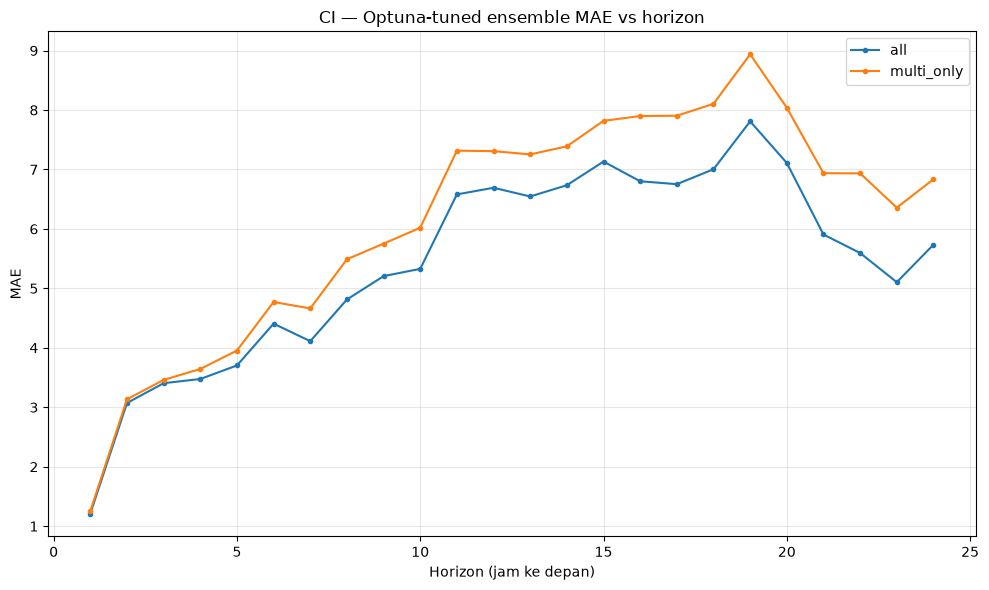

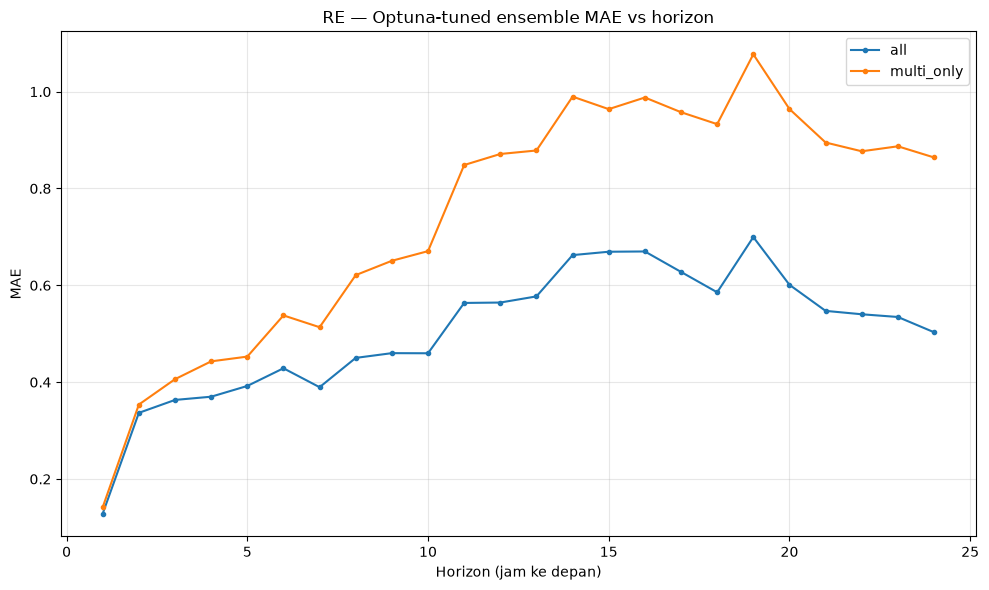

In [14]:
tuned_horizon_results = []

for target_name in ["CI", "RE"]:
    for label in ["all", "multi_only"]:
        if (target_name, label) not in tuned_weights:
            continue
        weights_dict = tuned_weights[(target_name, label)]

        for origin in shared_origins:
            combined = np.zeros(MULTISTEP_HORIZON)
            for key, w in weights_dict.items():
                combined += w * base_multistep_preds[key][target_name][origin]

            origin_index = test_raw.index[origin: origin + MULTISTEP_HORIZON]
            actual = df_core.loc[origin_index, CI_COL if target_name == "CI" else RE_COL].values

            for h in range(MULTISTEP_HORIZON):
                tuned_horizon_results.append({
                    "Ensemble": f"Ensemble-OptunaTuned ({label})", "Target": target_name,
                    "Horizon": h + 1, "AbsError": abs(actual[h] - combined[h])
                })

tuned_horizon_df = pd.DataFrame(tuned_horizon_results)
tuned_horizon_summary = (
    tuned_horizon_df.groupby(["Ensemble", "Target", "Horizon"], as_index=False)["AbsError"]
    .mean().rename(columns={"AbsError": "MAE_at_horizon"})
)

for target_name in ["CI", "RE"]:
    fig, ax = plt.subplots(figsize=(10, 6))
    for label in ["all", "multi_only"]:
        subset = tuned_horizon_summary[
            (tuned_horizon_summary["Ensemble"] == f"Ensemble-OptunaTuned ({label})")
            & (tuned_horizon_summary["Target"] == target_name)
        ].sort_values("Horizon")
        if len(subset) == 0:
            continue
        ax.plot(subset["Horizon"], subset["MAE_at_horizon"], label=label, marker="o", markersize=3)

    ax.set_xlabel("Horizon (jam ke depan)")
    ax.set_ylabel("MAE")
    ax.set_title(f"{target_name} — Optuna-tuned ensemble MAE vs horizon")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

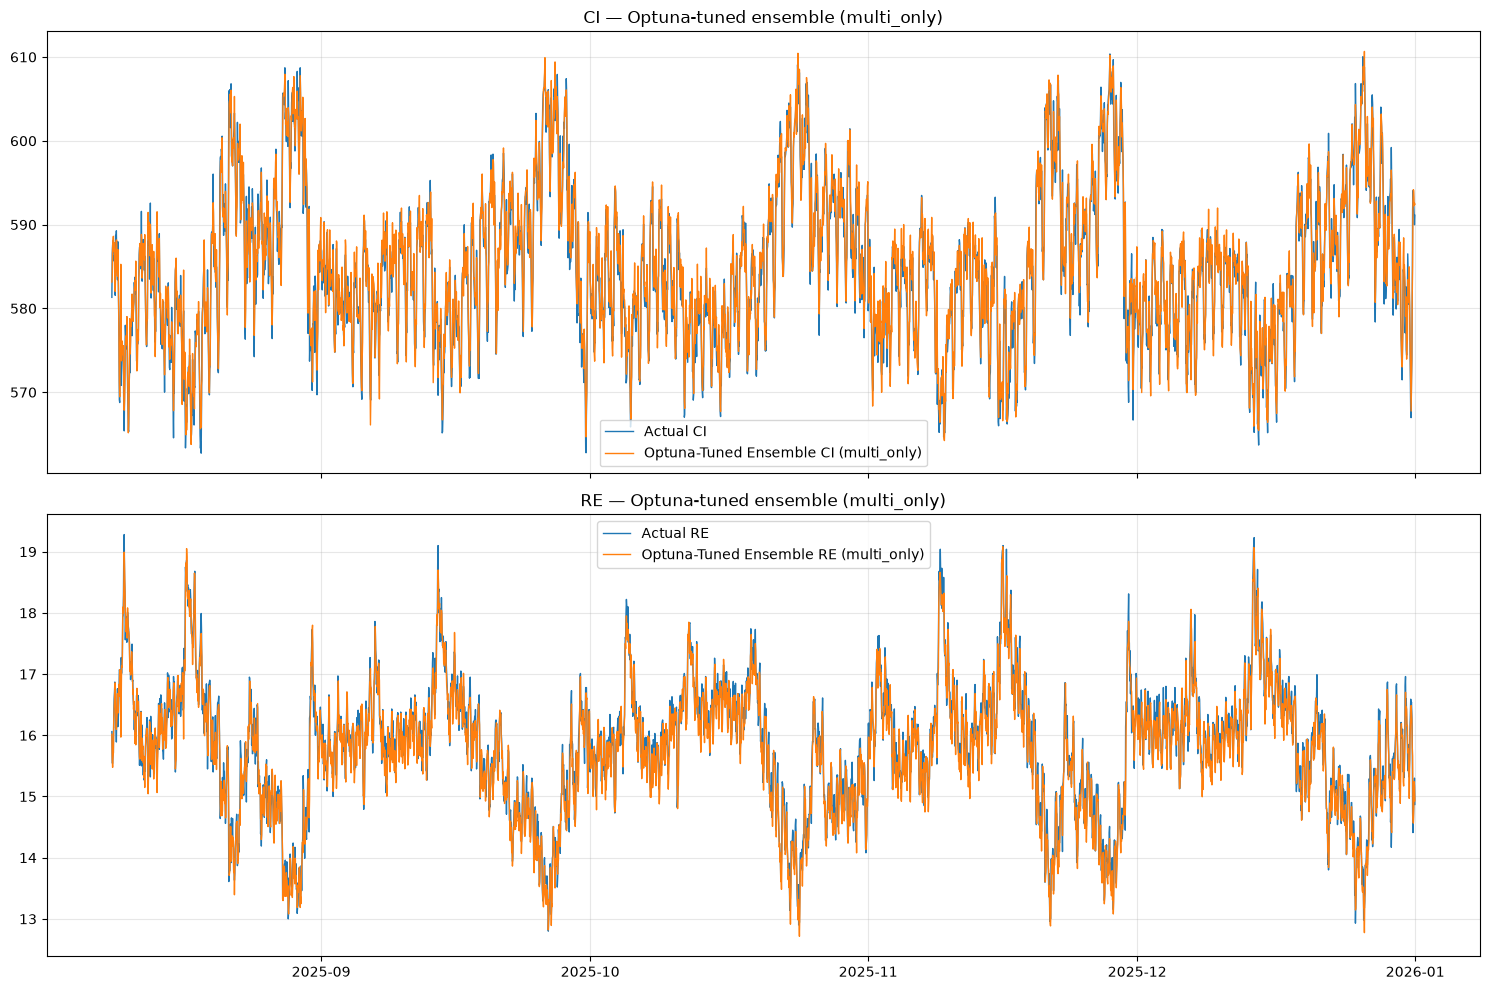

In [15]:
plot_index = common_test_index

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].plot(plot_index, df_core.loc[plot_index, CI_COL].values, label="Actual CI", linewidth=1)
axes[0].plot(plot_index, tuned_ensemble_predictions["CI"].values, label="Optuna-Tuned Ensemble CI (multi_only)", linewidth=1)
axes[0].set_title("CI — Optuna-tuned ensemble (multi_only)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_index, df_core.loc[plot_index, RE_COL].values, label="Actual RE", linewidth=1)
axes[1].plot(plot_index, tuned_ensemble_predictions["RE"].values, label="Optuna-Tuned Ensemble RE (multi_only)", linewidth=1)
axes[1].set_title("RE — Optuna-tuned ensemble (multi_only)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
results_dir = project_root / "results" / "ensemble_tuned"
results_dir.mkdir(parents=True, exist_ok=True)

weight_rows = []
for (target_name, label), weights_dict in tuned_weights.items():
    for key, w in weights_dict.items():
        weight_rows.append({"Target": target_name, "Subset": label, "Decomposition": key[0], "Model": key[1], "Weight": w})
pd.DataFrame(weight_rows).to_csv(results_dir / f"10_dani_ensemble_tuned_weights_{SOURCE}.csv", index=False)

tuned_ensemble_results_df.to_csv(results_dir / f"10_dani_ensemble_tuned_onestep_metrics_{SOURCE}.csv", index=False)
tuned_horizon_summary.to_csv(results_dir / f"10_dani_ensemble_tuned_multistep_horizon_mae_{SOURCE}.csv", index=False)

print("Saved results to:", results_dir, f"(SOURCE={SOURCE})")

Saved results to: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/ensemble_tuned (SOURCE=nb07)


## Ringkasan

- **`tuned_weights`** — bobot optimal hasil Optuna per target & subset (`all`, `multi_only`), bukan lagi
  heuristik `1/RMSE`.
- **`tuned_ensemble_results_df`** — evaluasi one-step dengan bobot tuned, siap dibandingkan langsung ke
  `results/ensemble/09_dani_ensemble_onestep_metrics_*.csv` (heuristik) dan performa model individu.

Yang perlu diperiksa:
1. Cek print **"Improvement over best individual"** — apakah bobot hasil Optuna akhirnya beneran
   mengungguli model tunggal terbaik (terutama untuk RE, yang di nb09 ensemble-nya malah kalah).
2. Lihat bobot per model yang di-print saat search — apakah Optuna menemukan pola yang masuk akal
   (misal, otomatis memberi bobot mendekati nol ke model Prophet yang lebih lemah)? Itu akan jadi bukti
   bahwa pendekatan weighted ensembling ini punya dasar yang kuat, bukan cuma "menaikkan angka".
3. Kalau ternyata **bahkan Optuna-tuned ensemble masih kalah/setara** dengan model tunggal terbaik —
   itu kesimpulan yang sah dan penting untuk laporan: untuk dataset ini, model hybrid tunggal terbaik
   sudah cukup kuat sehingga ensembling (dengan strategi apa pun) tidak memberikan keuntungan berarti.